# Artificial Neural Networks using Tensorflow and Keras

## Data Description

Data Source : https://www.kaggle.com/datasets/iabhishekofficial/mobile-price-classification/data

**About Dataset**

**Context**

Bob has started his own mobile company. He wants to give tough fight to big companies like Apple,Samsung etc.

He does not know how to estimate price of mobiles his company creates. In this competitive mobile phone market you cannot simply assume things. To solve this problem he collects sales data of mobile phones of various companies.

Bob wants to find out some relation between features of a mobile phone(eg:- RAM,Internal Memory etc) and its selling price. But he is not so good at Machine Learning. So he needs your help to solve this problem.

In this problem you do not have to predict actual price but a price range indicating how high the price is

## Mounting to Drive and Import Libraries

In [ ]:
# code for mounting to drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# importing all libraries needed

import pandas as pd #for data processing
import numpy as np #for support calculating
import matplotlib.pyplot as plt #for data visualization

from sklearn.model_selection import train_test_split #for split data into train and test
from sklearn.preprocessing import StandardScaler, OneHotEncoder #for data transformation
from sklearn.metrics import classification_report #for calculating metric performance of model

#tensorflow is for build neural network architecture
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import layers

# Read Data

In [ ]:
# replace this file_path with your dataset directory
file_path = "train.csv"

In [ ]:
# read data using pandas
df = pd.read_csv(file_path)
df.shape

(2000, 21)

In [ ]:
# showing first 5 data
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [ ]:
# showing data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

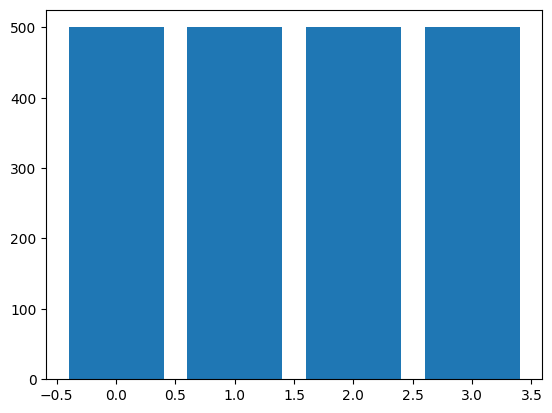

In [ ]:
# showing distribution of label data
plt.bar(df['price_range'].value_counts().index, df['price_range'].value_counts().values)
plt.show()

## Data Processing

In [ ]:
# define X (features) and Y (target) variable
X = df.drop('price_range', axis=1)
y = df['price_range']

In [ ]:
# split data into data train and data test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# scaling data with standard scaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
print(f"Shape of X_train : {X_train.shape}")
print(f"Shape of X_test : {X_test.shape}")

Shape of X_train : (1600, 20)
Shape of X_test : (400, 20)


In [ ]:
# transform y into vector, label : [0] -> [0,1,0,0]
encoder = OneHotEncoder()
y_train_encoded = encoder.fit_transform(y_train.values.reshape(-1, 1)).toarray()
y_test_encoded = encoder.transform(y_test.values.reshape(-1, 1)).toarray()

In [ ]:
print(f"Shape of y_train : {y_train_encoded.shape}")
print(f"Shape of y_test : {y_test_encoded.shape}")

Shape of y_train : (1600, 4)
Shape of y_test : (400, 4)


## Train the Model

In [ ]:
# design ANN architecture
model = Sequential()
model.add(layers.Input(shape=(X_train.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(4, activation='softmax'))

# complie model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
# training ANN
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.2541 - loss: 1.4047 - val_accuracy: 0.3275 - val_loss: 1.3594
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3018 - loss: 1.3617 - val_accuracy: 0.3450 - val_loss: 1.3202
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3920 - loss: 1.3180 - val_accuracy: 0.3800 - val_loss: 1.2663
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4459 - loss: 1.2498 - val_accuracy: 0.4200 - val_loss: 1.1922
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4857 - loss: 1.1812 - val_accuracy: 0.4800 - val_loss: 1.1141
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5189 - loss: 1.1045 - val_accuracy: 0.5275 - val_loss: 1.0431
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5483 - loss: 1.0424 - val_accuracy: 0.5925 - val_loss: 0.9808
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6207 - loss: 0.9643 - val_accuracy: 0.6375 - v

## Evaluate and Save Model

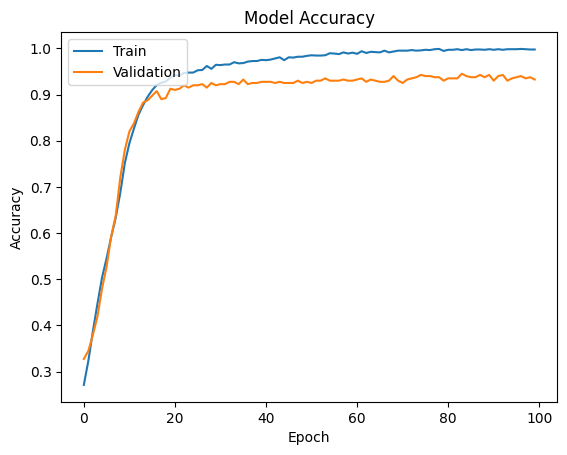

In [ ]:
# plot historical accuracy of model
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

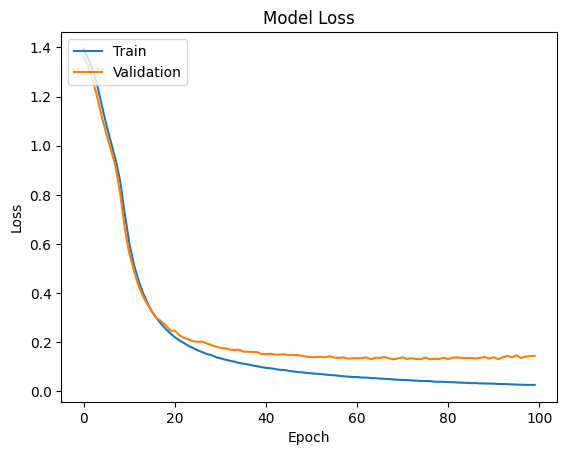

In [ ]:
# plot historical loss of model
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

In [ ]:
# calculate metric performance
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred_classes))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
              precision    recall  f1-score   support

           0       0.95      0.91      0.93       105
           1       0.90      0.95      0.92        91
           2       0.92      0.93      0.93        92
           3       0.95      0.94      0.95       112

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.93       400
weighted avg       0.93      0.93      0.93       400



In [ ]:
# save model locally
model.save('model.keras')

## Conclusion

We developed an Artificial Neural Network (ANN) classification model, trained over 100 epochs. The model achieved an accuracy of 0.93, with F1-scores for each label ranging from 0.92 to 0.95.These results indicate robust classification performance and accurate label recognition, with no signs of overfitting.